In [1]:
# 공공데이터 스타일 데이터 생성 (따릉이 일별 대여 기록 — 가상)
import numpy as np
import pandas as pd
np.random.seed(7)
n_days = 180
dates = pd.date_range("2025-01-01", periods=n_days, freq="D")
# 계절성: 봄·여름에 대여 증가
seasonal = 3000 + 2500 * np.sin(np.linspace(0, np.pi, n_days))
rentals = (seasonal + np.random.normal(0, 400, n_days)).round().astype(int)

bike = pd.DataFrame({
    "date": dates,
    "rentals": rentals,
    "avg_temp": (np.linspace(-2, 28, n_days) + np.random.normal(0, 2, n_days)).round(1),
    "rainfall": np.random.choice([0, 0, 0, 0, 5, 12, 30], n_days),
    "station_area": np.random.choice(["강남", "마포", "송파", "종로", " 강남 "], n_days),
})
# 오염 심기: 대여수 결측, 기온 이상치, 중복 행
bike.loc[np.random.choice(n_days, 8, replace=False), "rentals"] = np.nan
bike.loc[50, "avg_temp"] = 250.0     # 센서 오류로 보이는 이상치
bike = pd.concat([bike, bike.iloc[[3]]], ignore_index=True)  # 중복 1건

print("따릉이 데이터 준비 완료:", bike.shape)
bike.head()

따릉이 데이터 준비 완료: (181, 5)


,date,rentals,avg_temp,rainfall,station_area
0,2025-01-01,3676.0,-3.0,12,마포
1,2025-01-02,2857.0,-1.1,0,마포
2,2025-01-03,3101.0,-1.1,0,강남
3,2025-01-04,3295.0,0.9,0,강남
4,2025-01-05,2860.0,-1.1,0,마포


In [2]:
bike.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          181 non-null    datetime64[us]
 1   rentals       173 non-null    float64       
 2   avg_temp      181 non-null    float64       
 3   rainfall      181 non-null    int64         
 4   station_area  181 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 7.2 KB


In [3]:
bike["date"].max()

Timestamp('2025-06-29 00:00:00')

In [4]:
bike["rentals"].mean()

np.float64(4531.757225433526)

In [5]:
bike["avg_temp"].max()

np.float64(250.0)

In [6]:
bike.isnull().sum()

date            0
rentals         8
avg_temp        0
rainfall        0
station_area    0
dtype: int64

In [7]:
bike.duplicated().sum()

np.int64(1)

In [8]:
bike["station_area"].unique()

<StringArray>
['마포', ' 강남 ', '강남', '송파', '종로']
Length: 5, dtype: str

In [9]:
bike["station_area"].nunique("강남 ")

5

In [10]:
bike.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
176    False
177    False
178    False
179    False
180     True
Length: 181, dtype: bool

In [11]:
bike.tail()

,date,rentals,avg_temp,rainfall,station_area
176,2025-06-26,3516.0,22.9,0,강남
177,2025-06-27,3312.0,27.8,0,송파
178,2025-06-28,2514.0,27.4,0,송파
179,2025-06-29,3266.0,26.4,0,강남
180,2025-01-04,3295.0,0.9,0,강남


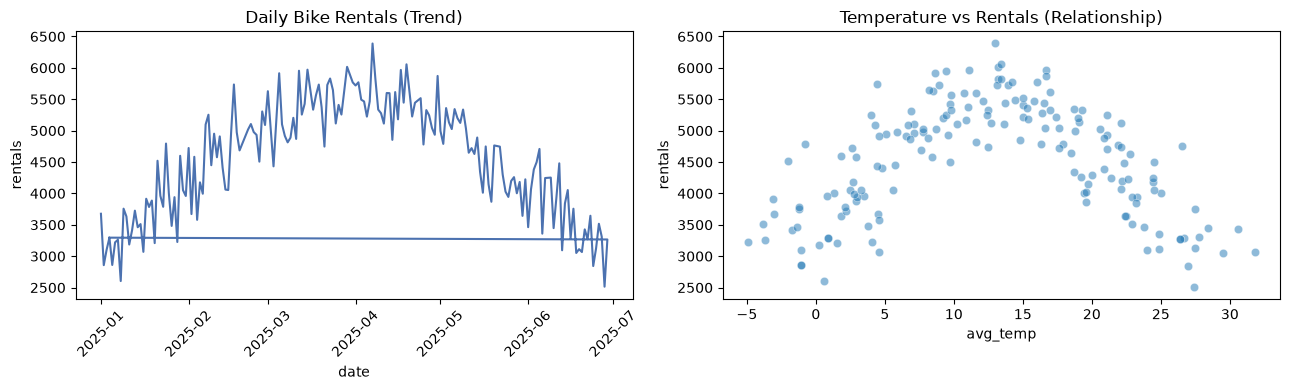

In [12]:
# 시나리오 3 — 시각화 (이상치 제거 후)
import matplotlib.pyplot as plt
import seaborn as sns
clean = bike[(bike["avg_temp"] < 60)].dropna(subset=["rentals"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# 추이
axes[0].plot(clean["date"], clean["rentals"], color="#4C72B0")
axes[0].set_title("Daily Bike Rentals (Trend)")
axes[0].set_xlabel("date"); axes[0].set_ylabel("rentals")
axes[0].tick_params(axis="x", rotation=45)
# 관계
sns.scatterplot(data=clean, x="avg_temp", y="rentals", alpha=0.5, ax=axes[1])
axes[1].set_title("Temperature vs Rentals (Relationship)")
axes[1].set_xlabel("avg_temp"); axes[1].set_ylabel("rentals")
plt.tight_layout(); plt.show()

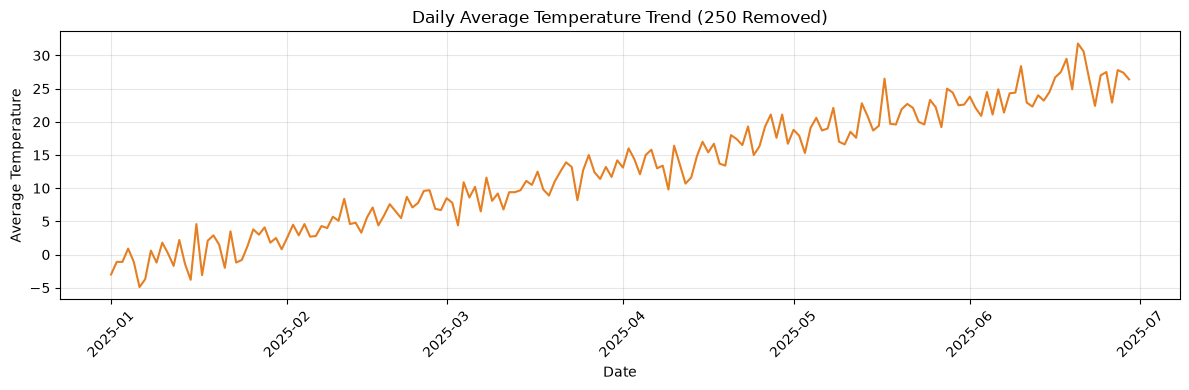

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 날짜 형식 변환
bike["date"] = pd.to_datetime(bike["date"])

# 평균 온도 250 제거
clean_temp = bike[bike["avg_temp"] != 250]

# 날짜별 평균 온도 계산
daily_temp = clean_temp.groupby("date")["avg_temp"].mean().reset_index()

# 그래프
plt.figure(figsize=(12, 4))

plt.plot(
    daily_temp["date"],
    daily_temp["avg_temp"],
    color="#E67E22"
)

plt.title("Daily Average Temperature Trend (250 Removed)")
plt.xlabel("Date")
plt.ylabel("Average Temperature")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
bike["avg_temp"].mean()

np.float64(14.169060773480664)

In [15]:
bike["station_area"].unique()

<StringArray>
['마포', ' 강남 ', '강남', '송파', '종로']
Length: 5, dtype: str

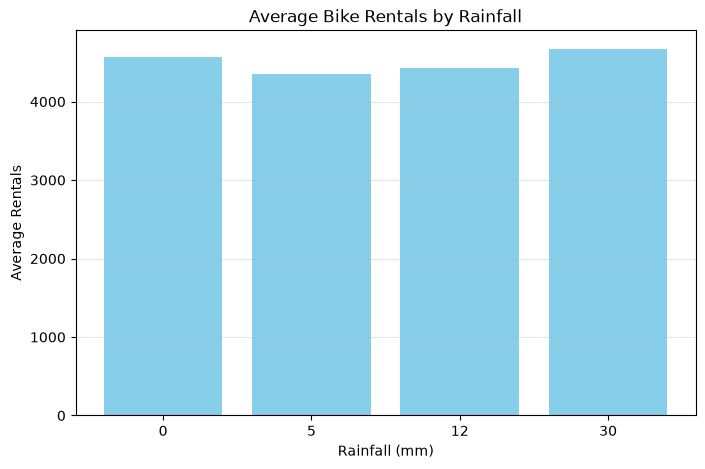

In [19]:
import matplotlib.pyplot as plt

# 결측치/중복 제거 후 분석용 데이터
bike_analysis = bike.drop_duplicates().dropna(subset=['rentals'])

# 강수량별 평균 대여량
rainfall_group = (
    bike_analysis
    .groupby('rainfall')['rentals']
    .mean()
)

# 그래프
plt.figure(figsize=(8,5))

plt.bar(
    rainfall_group.index.astype(str),
    rainfall_group.values,
    color='skyblue'
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Average Rentals")
plt.title("Average Bike Rentals by Rainfall")

plt.grid(axis='y', alpha=0.3)
plt.show()

In [20]:
bike["rainfall"].unique()

array([12,  0, 30,  5])

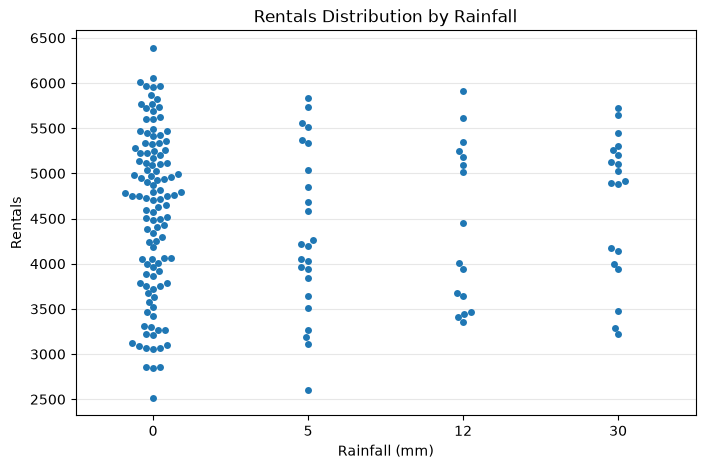

In [22]:
# 결측치/중복 제거
bike_analysis = bike.drop_duplicates().dropna(subset=['rentals'])

plt.figure(figsize=(8,5))

sns.swarmplot(
    data=bike_analysis,
    x='rainfall',
    y='rentals',
    size=5
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Rentals")
plt.title("Rentals Distribution by Rainfall")

plt.grid(axis='y', alpha=0.3)
plt.show()

In [33]:
bike["rainfall"].value_counts()

rainfall
0     118
5      25
30     21
12     17
Name: count, dtype: int64